In [1]:
def format_mcnp_block(values, columns=6, fmt=".6e"):
    """
    Formatte une liste de valeurs numériques pour un jeu de données MCNP.

    Paramètres
    ----------
    values : list or array-like
        Liste des valeurs à formater
    columns : int
        Nombre de colonnes par ligne (défaut : 6)
    fmt : str
        Format numérique des valeurs, ex :
        - ".6e" → notation scientifique avec 6 décimales (par défaut)
        - ".5f" → notation décimale fixe avec 5 chiffres après la virgule
        - ".3g" → format compact

    Retour
    ------
    str : bloc de texte formaté
    """
    lines = []
    line = []
    for i, val in enumerate(values):
        line.append(f"{val:{fmt}}")
        if (i + 1) % columns == 0:
            lines.append(" ".join(line))
            line = []
    if line:
        lines.append(" ".join(line))
    return "\n".join(lines)

# Distribution spatiale

In [7]:
# Fonctions pour Jupyter : subdivision selon deux logiques
# ===========================================================================
# 1) subdivide : fraction volumique (P_i_j = P_i * ((ru^3 - rl^3)/(r1^3 - r0^3)))
# 2) subdivide_legacy : logique ancienne (P_i_j = P_i * (1/3)*(ru^3 - rl^3))

import numpy as np
import pandas as pd


def subdivide(si, sp, subdiv, normalize=False):
    """
    Subdivise les mailles selon la fraction volumique :
    P_i_j = P_i * ((r_u^3 - r_l^3) / (r1^3 - r0^3))

    si : liste des bornes de maille (len n+1)
    sp : liste des probabilités par maille (len n)
    subdiv : int, nombre de sous-mailles par maille
    normalize : bool, si True, renormalise la somme totale à 1

    Retourne deux arrays (si2, sp2) de longueur n*subdiv
    """
    si2 = []
    sp2 = []
    for r0, r1, Pi in zip(si[:-1], si[1:], sp):
        dr = (r1 - r0) / subdiv
        for k in range(subdiv):
            rl = r0 + k * dr
            ru = rl + dr
            si2.append(ru)
            fraction = (ru**3 - rl**3) / (r1**3 - r0**3)
            sp2.append(Pi * fraction)

    si2 = np.array(si2)
    sp2 = np.array(sp2)
    if normalize:
        total = sp2.sum()
        if total <= 0:
            raise ValueError("Somme des probabilités ≤ 0, impossible à normaliser")
        sp2 = sp2 / total
    return si2, sp2


def subdivide_legacy(si, sp, subdiv, normalize=False):
    """
    Subdivise les mailles selon la logique "legacy" :
    P_i_j = P_i * (1/3)*(r_u^3 - r_l^3)

    si : liste des bornes de maille (len n+1)
    sp : liste des probabilités par maille (len n)
    subdiv : int, nombre de sous-mailles par maille
    normalize : bool, si True, renormalise la somme totale à 1

    Retourne deux arrays (si2, sp2) de longueur n*subdiv
    """
    si2 = []
    sp2 = []
    for r0, r1, Pi in zip(si[:-1], si[1:], sp):
        dr = (r1 - r0) / subdiv
        for k in range(subdiv):
            rl = r0 + k * dr
            ru = rl + dr
            si2.append(ru)
            weight = (1/3) * (ru**3 - rl**3)
            sp2.append(Pi * weight)

    si2 = np.array(si2)
    sp2 = np.array(sp2)
    if normalize:
        total = sp2.sum()
        if total <= 0:
            raise ValueError("Somme des probabilités ≤ 0, impossible à normaliser")
        sp2 = sp2 / total
    return si2, sp2

# U-C1 [U(4.95)O2F2 (H/235U = 410)]
# si = [0.00000, 9.41182, 11.85815, 13.57419, 14.94033, 16.09398, 17.10241, 18.00416, 18.82363, 19.57737, 20.27714, 20.93169, 21.54768, 22.13033, 22.68382, 23.21154, 23.71629, 24.20043, 24.66594, 25.11451, 25.54760]
# sp = [0.121732, 0.105443, 0.093971, 0.084567, 0.076452, 0.069243, 0.062763, 0.056842, 0.051373, 0.046292, 0.041526, 0.037025, 0.032748, 0.028655, 0.024712, 0.020882, 0.017137, 0.013409, 0.009637, 0.005590]
# subdiv = 50

# U-C4 [U(93.2) (H/235U = 0)]
# si = [0.00000, 3.18735, 4.01581, 4.59695, 5.0596, 5.45029, 5.7918, 6.09718, 6.3747, 6.62996, 6.86694, 7.0886, 7.29721, 7.49453, 7.68197, 7.86068, 8.03162, 8.19558, 8.35322, 8.50513, 8.6518]
# sp = [0.09618, 0.08617, 0.07897, 0.07299, 0.06776, 0.06309, 0.05883, 0.05491, 0.05126, 0.04784, 0.04463, 0.04158, 0.03868, 0.03591, 0.03324, 0.03066, 0.02814, 0.02564, 0.02312, 0.02039]
# subdiv = 50

# Pu-C1 (HPu0000)
si = [0.00000, 1.81623, 2.28830, 2.61945, 2.88308, 3.10571, 3.30030, 3.47432, 3.63246, 3.77791, 3.91294, 4.03925, 4.15812, 4.27056, 4.37737, 4.47920, 4.57661, 4.67003, 4.75986, 4.84642, 4.93000]
sp = [0.08801, 0.08002, 0.07424, 0.06938, 0.06512, 0.06128, 0.05775, 0.05448, 0.05142, 0.04854, 0.04581, 0.04320, 0.04070, 0.03829, 0.03596, 0.03369, 0.03145, 0.02922, 0.02695, 0.02448]
subdiv = 50

# # # Pu-C4 (HPu0900)
# si = [0.00000, 7.18386, 9.05110, 10.36092, 11.40367, 12.28423, 13.05394, 13.74223, 14.36772, 14.94303, 15.47716, 15.97676, 16.44694, 16.89166, 17.31413, 17.71693, 18.10220, 18.47173, 18.82704, 19.16943, 19.50000]
# sp = [0.11826, 0.10308, 0.09232, 0.08348, 0.07581, 0.06899, 0.06279, 0.05713, 0.05186, 0.04692, 0.04227, 0.03785, 0.03362, 0.02955, 0.02561, 0.02175, 0.01796, 0.01419, 0.01035, 0.00622]
# subdiv = 50

# Fraction volumique (P_i_j = P_i * ((r_u^3 - r_l^3)/(r1^3 - r0^3)))
si2, sp2 = subdivide(si, sp, subdiv, normalize=False)
df = pd.DataFrame({'r (cm)': si2, 'P': sp2})
df['P'] = df['P'].map('{:.2e}'.format)
print("-- Fraction volumique --")
print(df.head())

# Logique legacy (P_i_j = P_i * (1/3)*(r_u^3 - r_l^3))
si2_legacy, sp2_legacy = subdivide_legacy(si, sp, subdiv, normalize=False)
df2 = pd.DataFrame({'r (cm)': si2_legacy, 'P_legacy': sp2_legacy})
print("\n-- Legacy (Marc Troisne) --")
df2['P_legacy'] = df2['P_legacy'].map('{:.2e}'.format)
print(df2.head())



-- Fraction volumique --
     r (cm)         P
0  0.036325  7.04e-07
1  0.072649  4.93e-06
2  0.108974  1.34e-05
3  0.145298  2.61e-05
4  0.181623  4.29e-05

-- Legacy (Marc Troisne) --
     r (cm)  P_legacy
0  0.036325  1.41e-06
1  0.072649  9.84e-06
2  0.108974  2.67e-05
3  0.145298  5.20e-05
4  0.181623  8.58e-05


In [8]:
# Formatage texte
mcnp_text = format_mcnp_block(si2, columns=6, fmt=".5f")
# Écriture dans le fichier
output_file = "si2.txt"
with open(output_file, "w") as f:
    f.write(mcnp_text)

print(f"Fichier sauvegardé sous : {output_file}")

Fichier sauvegardé sous : si2.txt


In [9]:
# Formatage texte
mcnp_text = format_mcnp_block(sp2, columns=6, fmt=".5e")
# Écriture dans le fichier
output_file = "sp2.txt"
with open(output_file, "w") as f:
    f.write(mcnp_text)

print(f"Fichier sauvegardé sous : {output_file}")

Fichier sauvegardé sous : sp2.txt


# Distribution énergétique

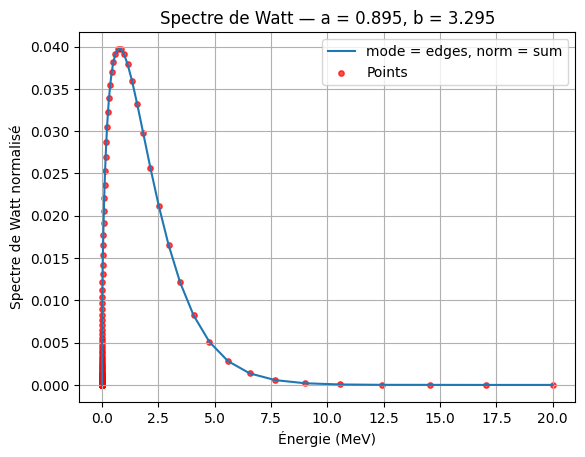

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def spectre_watt(a, b, energy_bins, mode="center", normalize_mode="integral", plot=False):
    """
    Génère un spectre de Watt normalisé selon deux modes : "integral" ou "sum".

    Paramètres
    ----------
    a : float
        Paramètre "a" du spectre (MeV)
    b : float
        Paramètre "b" du spectre (MeV^-1)
    energy_bins : array-like
        Binning en énergie (bords des bins)
    mode : str
        "center" (par défaut) ou "edges" pour évaluer le spectre
    plot : bool
        Si True, affiche le spectre
    normalize_mode : str
        "integral" (par défaut) : normalise ∑(spectrum * dx) = 1
        "sum" : normalise ∑(spectrum) = 1

    Retour
    ------
    x : ndarray
        Points d'énergie (centres ou bords selon le mode)
    spectrum : ndarray
        Valeurs normalisées du spectre de Watt
    cdf : ndarray
        Fonction de répartition cumulée (CDF)
    """
    energy_bins = np.asarray(energy_bins)

    if mode == "center":
        x = 0.5 * (energy_bins[:-1] + energy_bins[1:])
        dx = np.diff(energy_bins)
    elif mode == "edges":
        x = energy_bins
        dx = np.zeros_like(x)
        dx[1:-1] = 0.5 * (np.diff(x[:-1]) + np.diff(x[1:]))
        dx[0] = x[1] - x[0]
        dx[-1] = x[-1] - x[-2]
    else:
        raise ValueError("mode must be 'center' or 'edges'")

    spectrum = np.exp(-x / a) * np.sinh(np.sqrt(b * x))

    # Normalisation
    if normalize_mode == "integral":
        norm = np.sum(spectrum * dx)
    elif normalize_mode == "sum":
        norm = np.sum(spectrum)
    else:
        raise ValueError("normalize_mode must be 'integral' or 'sum'")

    spectrum /= norm

    # CDF : toujours calculée comme somme pondérée
    cdf = np.cumsum(spectrum * dx)

    if plot:
        plt.plot(x, spectrum, label=f"mode = {mode}, norm = {normalize_mode}")
        plt.scatter(x, spectrum, color='red', s=15, alpha=0.7, label="Points")  # Ajout des points
        plt.xlabel("Énergie (MeV)")
        plt.ylabel("Spectre de Watt normalisé")
        plt.title(f"Spectre de Watt — a = {a:.3f}, b = {b:.3f}")
        plt.grid(True)
        plt.legend()
        plt.show()

    return x, spectrum, cdf

# Exemple d'utilisation
# # si11_edges = [1.00000E-11, 8.09343E-02, 1.30093E-01, 1.72311E-01, 2.10792E-01, 2.46854E-01, 2.81200E-01, 3.14259E-01, 3.46321E-01, 3.77590E-01, 4.08217E-01, 4.38321E-01, 4.67994E-01, 4.97313E-01, 5.26339E-01, 5.55125E-01, 5.83717E-01, 6.12154E-01, 6.40471E-01, 6.68699E-01, 6.96865E-01, 7.24994E-01, 7.53109E-01, 7.81232E-01, 8.09383E-01, 8.37580E-01, 8.65841E-01, 8.94182E-01, 9.22621E-01, 9.51172E-01, 9.79851E-01, 1.00867E+00, 1.03765E+00, 1.06680E+00, 1.09614E+00, 1.12568E+00, 1.15543E+00, 1.18541E+00, 1.21563E+00, 1.24611E+00, 1.27687E+00, 1.30791E+00, 1.33926E+00, 1.37093E+00, 1.40293E+00, 1.43529E+00, 1.46802E+00, 1.50115E+00, 1.53468E+00, 1.56863E+00, 1.60304E+00, 1.63792E+00, 1.67330E+00, 1.70919E+00, 1.74562E+00, 1.78263E+00, 1.82023E+00, 1.85846E+00, 1.89735E+00, 1.93693E+00, 1.97724E+00, 2.01832E+00, 2.06021E+00, 2.10294E+00, 2.14658E+00, 2.19116E+00, 2.23674E+00, 2.28339E+00, 2.33117E+00, 2.38013E+00, 2.43037E+00, 2.48197E+00, 2.53500E+00, 2.58958E+00, 2.64582E+00, 2.70383E+00, 2.76374E+00, 2.82572E+00, 2.88994E+00, 2.95657E+00, 3.02583E+00, 3.09798E+00, 3.17329E+00, 3.25208E+00, 3.33474E+00, 3.42169E+00, 3.51347E+00, 3.61068E+00, 3.71407E+00, 3.82456E+00, 3.94327E+00, 4.07162E+00, 4.21145E+00, 4.36516E+00, 4.53600E+00, 4.72856E+00, 4.94951E+00, 5.20927E+00, 5.52529E+00, 5.93055E+00, 6.50000E+00, 7.01923E+00, 7.53846E+00, 8.05769E+00, 8.57692E+00, 9.09615E+00, 9.61538E+00, 1.01346E+01, 1.06538E+01, 1.11731E+01, 1.16923E+01, 1.22115E+01, 1.27308E+01, 1.32500E+01, 1.37692E+01, 1.42885E+01, 1.48077E+01, 1.53269E+01, 1.58462E+01, 1.63654E+01, 1.68846E+01, 1.74038E+01, 1.79231E+01, 1.84423E+01, 1.89615E+01, 1.94808E+01, 2.00000E+01]
# si12_edges = [1.00000E-11, 8.27876E-02, 1.32936E-01, 1.75926E-01, 2.15050E-01, 2.51664E-01, 2.86491E-01, 3.19975E-01, 3.52412E-01, 3.84013E-01, 4.14936E-01, 4.45300E-01, 4.75203E-01, 5.04721E-01, 5.33920E-01, 5.62854E-01, 5.91570E-01, 6.20107E-01, 6.48502E-01, 6.76785E-01, 7.04987E-01, 7.33131E-01, 7.61242E-01, 7.89342E-01, 8.17450E-01, 8.45585E-01, 8.73767E-01, 9.02011E-01, 9.30334E-01, 9.58751E-01, 9.87279E-01, 1.01593E+00, 1.04472E+00, 1.07367E+00, 1.10278E+00, 1.13208E+00, 1.16157E+00, 1.19128E+00, 1.22121E+00, 1.25138E+00, 1.28180E+00, 1.31249E+00, 1.34347E+00, 1.37475E+00, 1.40635E+00, 1.43828E+00, 1.47056E+00, 1.50321E+00, 1.53625E+00, 1.56969E+00, 1.60357E+00, 1.63789E+00, 1.67268E+00, 1.70797E+00, 1.74377E+00, 1.78012E+00, 1.81704E+00, 1.85457E+00, 1.89272E+00, 1.93154E+00, 1.97106E+00, 2.01131E+00, 2.05234E+00, 2.09419E+00, 2.13690E+00, 2.18053E+00, 2.22512E+00, 2.27074E+00, 2.31744E+00, 2.36530E+00, 2.41439E+00, 2.46478E+00, 2.51657E+00, 2.56985E+00, 2.62474E+00, 2.68135E+00, 2.73981E+00, 2.80027E+00, 2.86290E+00, 2.92789E+00, 2.99544E+00, 3.06581E+00, 3.13925E+00, 3.21611E+00, 3.29674E+00, 3.38159E+00, 3.47118E+00, 3.56611E+00, 3.66714E+00, 3.77519E+00, 3.89140E+00, 4.01720E+00, 4.15449E+00, 4.30572E+00, 4.47430E+00, 4.66503E+00, 4.88505E+00, 5.14570E+00, 5.46656E+00, 5.88626E+00, 6.50000E+00, 7.01923E+00, 7.53846E+00, 8.05769E+00, 8.57692E+00, 9.09615E+00, 9.61538E+00, 1.01346E+01, 1.06538E+01, 1.11731E+01, 1.16923E+01, 1.22115E+01, 1.27308E+01, 1.32500E+01, 1.37692E+01, 1.42885E+01, 1.48077E+01, 1.53269E+01, 1.58462E+01, 1.63654E+01, 1.68846E+01, 1.74038E+01, 1.79231E+01, 1.84423E+01, 1.89615E+01, 1.94808E+01, 2.00000E+01]
# # 🔁 Normalisation par intégrale (cas physique) :
# # x, f, F = spectre_watt(0.89506, 3.2953, si12_edges, normalize_mode="integral")
# # 🧪 Normalisation par somme brute (par curiosité ou tests) :
# # E_center, S_center, _ = spectre_watt(0.89506, 3.2953, si12_edges, mode="center", normalize_mode="sum", plot=True)
# E_edges, S_edges, _ = spectre_watt(0.89506, 3.2953, si12_edges, mode="edges", normalize_mode="sum", plot=True)

# #U-C1 (#238U Thermal)
# a_watt = 0.88111
# b_watt = 3.4005
#U-C4 (#238U 1MeV)
a_watt = 0.89506 
b_watt = 3.2953
# U-C1 (#235U Thermal)
# a_watt = 0.988
# b_watt = 2.249
# U-C4 (#235U 1MeV)
# a_watt = 0.89506 
# b_watt = 3.2953

# # Pu-C1 (#9Pu 1MeV)
# a_watt = 0.966 
# b_watt = 2.842
# # Pu-C4 (#9PuThermal)
# a_watt = 0.966 
# b_watt = 2.842

bin_edges = np.logspace(np.log10(1E-9),np.log10(20), 150)
# bin_edges = np.linspace(1E-11, 20, 150)
E_edges, S_edges, _ = spectre_watt(a_watt, b_watt, bin_edges, mode="edges", normalize_mode="sum", plot=True)



In [6]:
# Formatage texte
mcnp_text = format_mcnp_block(E_edges, columns=6, fmt=".5e")
# Écriture dans le fichier
output_file = "si12.txt"
with open(output_file, "w") as f:
    f.write(mcnp_text)

print(f"Fichier sauvegardé sous : {output_file}")

Fichier sauvegardé sous : si12.txt


In [7]:
# Formatage texte
mcnp_text = format_mcnp_block(S_edges, columns=6, fmt=".5e")
# Écriture dans le fichier
output_file = "sp12.txt"
with open(output_file, "w") as f:
    f.write(mcnp_text)

print(f"Fichier sauvegardé sous : {output_file}")

Fichier sauvegardé sous : sp12.txt


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from watt import FWatt

# Instanciation de l'antidérivée normalisée de la loi de Watt
a_watt = 0.89506
b_watt = 3.2953
F = FWatt(a=a_watt, b=b_watt)  # paramètres à adapter 

# Binning en énergie (par exemple : les bords si12)
#energy_bins = np.linspace(1.0e-11, 20, 500) 
energy_bins = np.array(si12_edges)  

bin_centers = 0.5 * (energy_bins[:-1] + energy_bins[1:])

# Calcul du spectre : dérivée de F ≈ différence entre valeurs consécutives
cdf_vals = np.array([F(x) for x in energy_bins])
watt_ref = np.diff(cdf_vals)


# Comparaison avec ta fonction spectre_watt
E_center, watt_model, _ = spectre_watt(a_watt, b_watt, energy_bins, mode="center", normalize_mode="sum", plot=False)

# Tracé comparatif
plt.plot(E_center, watt_model, label="spectre_watt (modèle)", lw=2)
plt.plot(bin_centers, watt_ref, label="watt.py (intégrale)", lw=2, linestyle="--")
plt.xlabel("Énergie (MeV)")
plt.ylabel("Spectre normalisé")
plt.title("Comparaison entre deux implémentations du spectre de Watt")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'si12_edges' is not defined